In [2]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib import cm as cm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import explained_variance_score, median_absolute_error, r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split, cross_validate
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet, RANSACRegressor, SGDRegressor, HuberRegressor, BayesianRidge # Linear models
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor, ExtraTreesRegressor  # Ensemble methods
from xgboost import XGBRegressor, plot_importance 
from sklearn.svm import SVR, SVC, LinearSVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA, PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import learning_curve, validation_curve, GridSearchCV
from sklearn.base import clone
from sklearn.metrics import mean_squared_error as MSE
warnings.filterwarnings("ignore")
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
plt.style.use('seaborn-white')

In [3]:
df = pd.read_csv("../data/data_energy.csv")

In [4]:
df

,at,v,ap,rh,pe
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [5]:
target = "pe"
control_variables = ["at", "v"]
features = list(df.columns)
features.remove(target)


print("features /  Action Space: ", features)
print("control_variables: ", control_variables)
print("target: ", target)

target = target 
action_space = control_variables
observation_space = features


features /  Action Space:  ['at', 'v', 'ap', 'rh']
control_variables:  ['at', 'v']
target:  pe


In [6]:
target = "pe"
targ_corr_threshold = 0.5
features = list(df.columns)
features.remove(target)
seed = 20

def _define_problem(data, target):
    X = data[features]
    y = data[[target]]
    print("Matrix X:", X.shape)
    print("Vector y:", y.shape)
    return X, y

def _convert2float(df):
    for col in df.columns:
        df[col] = df[col].apply(float)
    return df

In [7]:
df = _convert2float(df)
X, y = _define_problem(df, target)

Matrix X: (9568, 4)
Vector y: (9568, 1)


# 1 model


In [8]:
model_pipeline = Pipeline([
    ("Scaler", MinMaxScaler()),
    ("Regressor", GradientBoostingRegressor())])

n_folds = 7
kfold = KFold(n_splits=n_folds)

scoring = ('r2', 'neg_mean_squared_error', 'neg_mean_absolute_percentage_error',
           'explained_variance', 'neg_mean_absolute_error', 'max_error', 'neg_root_mean_squared_error')

cv_results = cross_validate(model_pipeline,
                             X,
                             y,
                             cv=kfold,
                             scoring=scoring,
                             n_jobs=1)

In [9]:
for key in cv_results:
    mean = abs(cv_results[key].mean())
    print(key.replace("_neg", ""), ":", mean)

fit_time : 0.6185222012656075
score_time : 0.010862452643258231
test_r2 : 0.9480929101415599
test_mean_squared_error : 15.111340386177277
test_mean_absolute_percentage_error : 0.006503465897076776
test_explained_variance : 0.9481097336480647
test_mean_absolute_error : 2.95215677394608
test_max_error : 29.683806029536218
test_root_mean_squared_error : 3.88422493522502


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.15,
                                                    random_state=seed)

In [11]:

model_pipeline = Pipeline([
    ("Scaler", MinMaxScaler()),
    ("Regressor", GradientBoostingRegressor())])

model_pipeline = model_pipeline.fit(X_train, y_train)



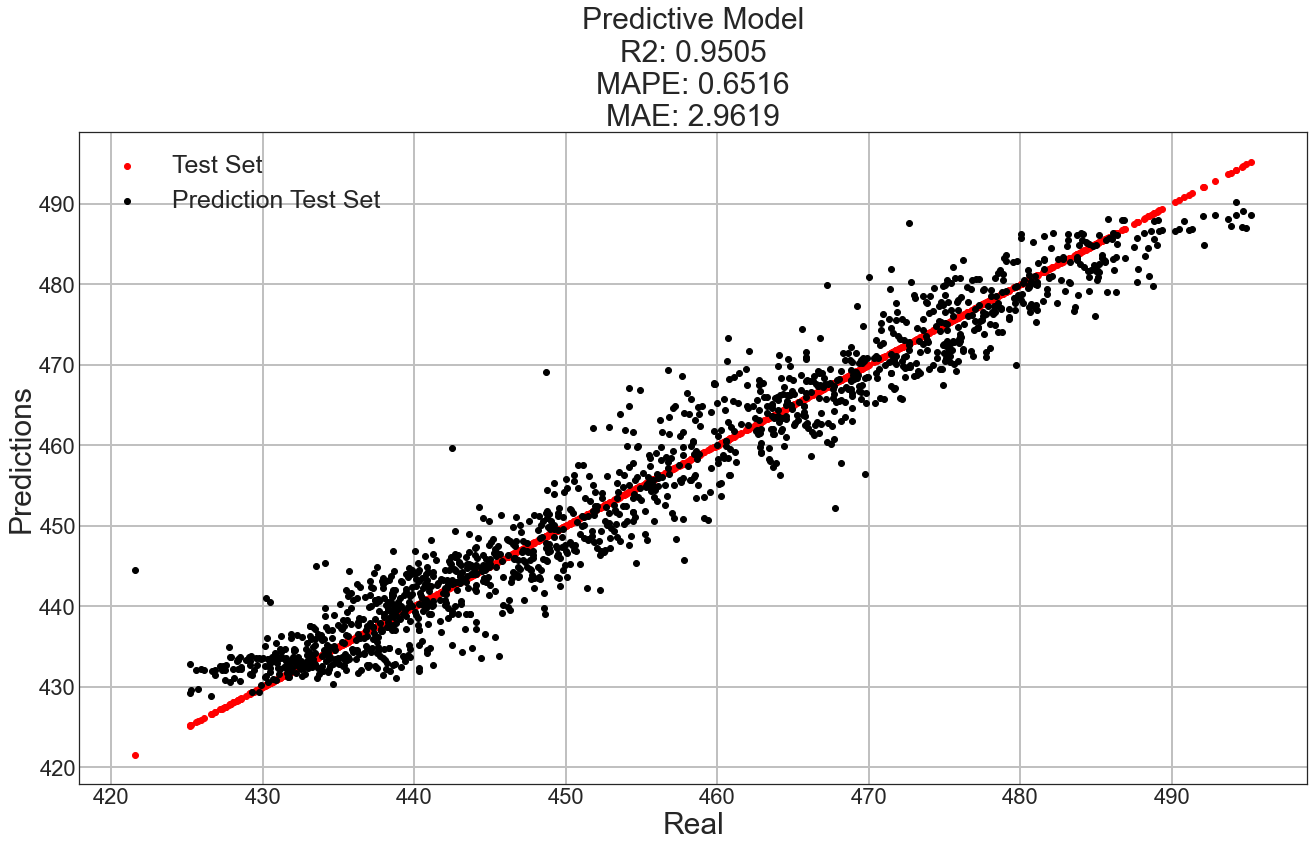

In [12]:
y_pred = model_pipeline.predict(X_test)


def plot_xy_results(y_pred, y_test, name="Regularized Regression"):
    y_pred = np.reshape(y_pred, (-1, 1)) 
    y_test = np.reshape(y_test, (-1, 1)) 
    letter_size = 20
    mae = np.abs(y_pred - y_test).mean()
    mae = mean_absolute_error(y_pred, y_test)
    mse = mean_squared_error(y_pred, y_test)
    rmse = np.sqrt(mean_squared_error(y_pred, y_test))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)
    mae = str(round(mae, 4))
    mape = str(round(mape, 4))
    mse = str(round(mse, 4))
    rmse = str(round(rmse, 4))
    r2 = str(round(r2, 4))

    fig, ax = plt.subplots(1, figsize=(22, 12))
    plt.scatter(y_test, y_test, color='red')
    plt.scatter(y_test, y_pred, color='k')
    title = f"{name}" + "\n" + f"R2: {r2}" + "\n" + f"MAPE: {str(mape)}" + "\n" + f"MAE: {str(mae)}"
    plt.title(title, fontsize=30)
    plt.xlabel('Real', fontsize=30)
    plt.ylabel('Predictions', fontsize=30)
    plt.grid(color='silver', linestyle='-', linewidth=2)
    ax.tick_params(axis='both', which='major', labelsize=22)
    plt.legend(['Test Set', 'Prediction Test Set'], loc='upper left',
               prop={'size': letter_size+5})
    plt.show()

plot_xy_results(y_pred, y_test, name="Predictive Model")

In [13]:
path_model = "../env_model/model_env.pkl"

with open(path_model, 'wb') as files:
    pickle.dump(model_pipeline, files)


with open(path_model, 'rb') as file:  
    trained_model = pickle.load(file)

In [14]:
trained_model

Pipeline(steps=[('Scaler', MinMaxScaler()),
                ('Regressor', GradientBoostingRegressor())])

In [15]:
y_pred = trained_model.predict(X_test)

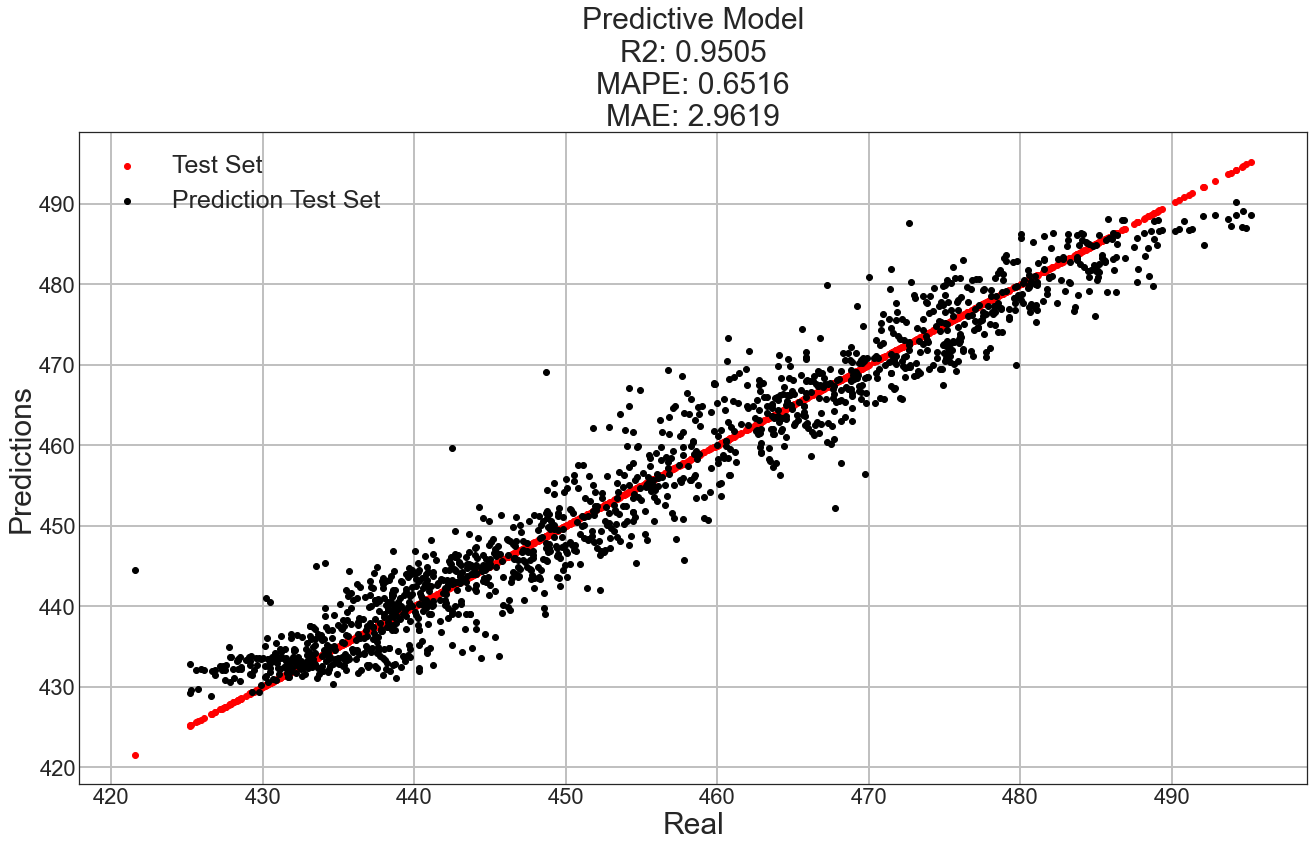

In [16]:
plot_xy_results(y_pred, y_test, name="Predictive Model")

In [24]:
X_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)


df_test

,at,v,ap,rh,pe
0,25.20,65.59,1013.00,71.34,439.14
1,22.19,48.78,1017.84,76.01,446.51
2,8.33,38.08,1018.94,73.78,481.89
3,10.73,44.92,1025.10,85.40,476.81
4,27.10,79.74,1005.43,86.05,431.51
...,...,...,...,...,...
1431,21.82,58.66,1011.71,64.37,452.16
1432,23.98,50.32,1008.41,67.75,443.45
1433,25.42,75.60,1017.39,77.63,438.24
1434,4.49,40.27,1012.01,76.50,494.24


In [27]:
df_train.to_csv("../data/data_energy_train.csv", index=False)
df_test.to_csv("../data/data_energy_test.csv", index=False)

In [30]:
df_test["prediction"] = model_pipeline.predict(df_test[features])


In [33]:
((df_test["pe"] - df_test["prediction"]) / df_test["pe"] * 100).apply(abs).mean()

0.65164764993112